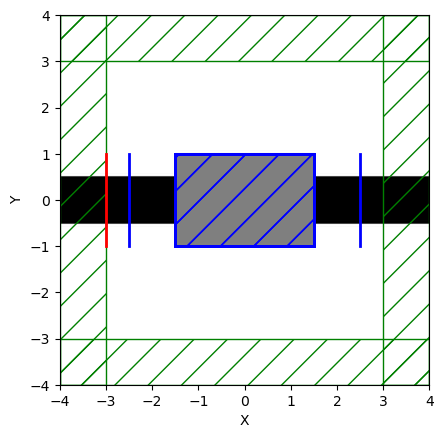

In [28]:
## mode converter ##
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import grad as ag_grad
import nlopt
import matplotlib.pyplot as plt

mp.verbosity(0)

Si = mp.Medium(index=3.4)

resolution = 30

# cell size
Sx = 8
Sy = 8
cell_size = mp.Vector3(Sx, Sy, 0)
pml_layers = [mp.PML(1.0)]
 

# source
fcen = 1 / 0.75 # 750nm
width = 0.2
fwidth = width * fcen
source_center = [-3, 0, 0]
source_size = mp.Vector3(0, 2, 0)
src = mp.GaussianSource(frequency = fcen, fwidth=fwidth)
source = [
    mp.EigenModeSource(
        src,
        eig_band=1,
        eig_match_freq=True,
        direction=mp.X,
        size=source_size,
        center=source_center,
        eig_parity=mp.ODD_Z
    )
]


# design region
Dx = 3
Dy = 2
design_region_resolution = int(resolution)

Nx = int(Dx * design_region_resolution + 1)
Ny = int(Dy * design_region_resolution + 1)

design_variables = mp.MaterialGrid(mp.Vector3(Nx, Ny),
                                   mp.air,
                                   Si,
                                   grid_type="U_MEAN")
design_region = mpa.DesignRegion(design_variables,
                                 volume=mp.Volume(center=mp.Vector3(),
                                                  size=mp.Vector3(Dx, Dy)))


# geometry 
geometry = [
    mp.Block(
            center=mp.Vector3(-2.75, 0),
            material=Si,
            size=mp.Vector3(2.5, 1, 0)
            ),
    mp.Block(
            center=mp.Vector3(2.75, 0),
            material=Si,
            size=mp.Vector3(2.5, 1, 0)
            ),
    mp.Block(
            center=design_region.center,
            material=design_variables,
            size=design_region.size
            )
]


# filter
filter_radius = 0.08 # 80nm
eta_i = (0.5)
eta_e = 0.55
eta_d = 1 - eta_e

def mapping(x, beta, eta):
    x_reshaped = npa.reshape(x, (Nx, Ny))

    # cone shaped filter
    x_filtered = mpa.conic_filter(
        x_reshaped, 
        filter_radius, 
        design_region.size.x,
        design_region.size.y,
        design_region_resolution
    )

    # projection
    x_proj = mpa.tanh_projection(x_filtered, beta, eta)

    return x_proj.flatten()


# simulation
sim =mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    resolution=resolution,
)


# objective function
TE00 = mpa.EigenmodeCoefficient(
    sim,
    mp.Volume(center=mp.Vector3(-2.5,0,0), size=mp.Vector3(y=2)),
    mode=1,
    eig_parity=mp.ODD_Z
)

TE20 = mpa.EigenmodeCoefficient(
    sim,
    mp.Volume(center=mp.Vector3(2.5,0,0), size=mp.Vector3(y=2)),
    mode=3,
    eig_parity=mp.ODD_Z
)

ob_list = [TE00, TE20]

def J(source, monitor):
    return npa.abs(monitor) ** 2 / npa.abs(source) ** 2


opt = mpa.OptimizationProblem(
    simulation=sim,
    objective_functions=[J],
    objective_arguments=ob_list,
    design_regions=[design_region],
    fcen=fcen,
    df=0,
    nf=1,
)

x0 = 0.5 * np.ones((Nx * Ny, ))
opt.update_design([x0])

opt.plot2D(True)
plt.show()




In [29]:
evaluation_history = []
sensitivity = [0]


def f(x, grad):
    f0, dJ_du = opt([x])
    f0 = f0[0]  # f0 is an array of length 1
    if grad.size > 0:
        grad[:] = np.squeeze(dJ_du)
    evaluation_history.append(np.real(f0))
    sensitivity[0] = dJ_du
    return np.real(f0)


algorithm = nlopt.LD_MMA
n = Nx * Ny
maxeval = 20

solver = nlopt.opt(algorithm, n)
solver.set_lower_bounds(0)
solver.set_upper_bounds(1)
solver.set_max_objective(f)
solver.set_maxeval(maxeval)

x = solver.optimize(x0)

Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating grad

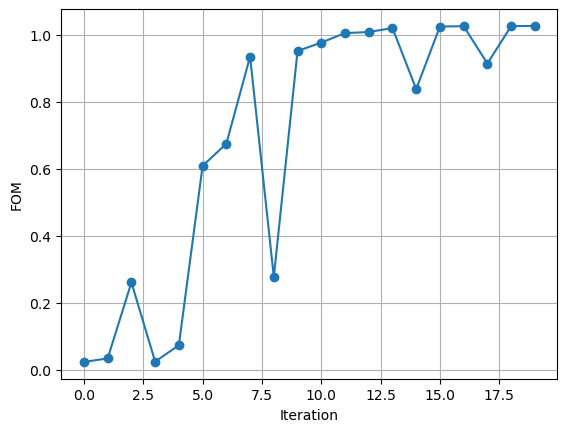

In [30]:
plt.figure()
plt.plot(evaluation_history, "o-")
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("FOM")
plt.show()

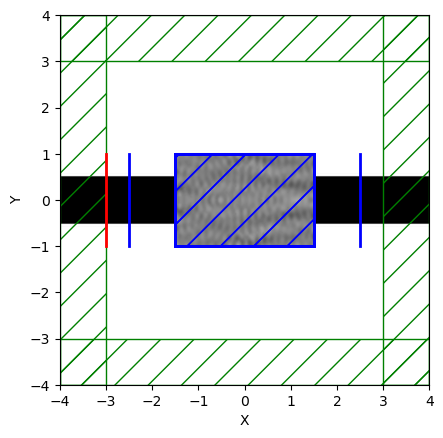

In [31]:
opt.plot2D(True)
plt.show()